# 05 — Model Comparison

Compares the environmental model (colonization pressure) and the patient model
(antibiotic exposure, age/sex-adjusted) on predictive performance, to answer the project's
core question: which better predicts hospital-onset MRSA acquisition?

**Caveat to carry into the write-up:** the two cohorts differ in matching design and
sample composition, so this is not a strictly apples-to-apples comparison — differences in
AUC partly reflect differences in the matched populations, not only differences in
predictor strength. Treat this as a scoped, directional comparison.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import RocCurveDisplay, roc_auc_score
from sklearn.model_selection import train_test_split

sys.path.append(str(Path.cwd().parent))
from src.data_loading import load_processed, drop_zero_variance

env = load_processed("environmental_mrsa.csv")
pat = load_processed("patient_mrsa.csv")

## Fit each model with an 80/20 train/test split (for fair AUC comparison)

In [2]:
def fit_and_eval(df, predictors, label, random_state=42):
    data = df[["group_binary"] + predictors].dropna()
    X, y = data[predictors], data["group_binary"]
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=random_state
    )
    clf = LogisticRegression(max_iter=2000)
    clf.fit(X_train, y_train)
    proba = clf.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, proba)
    print(f"{label}: n={len(data)}, test AUC={auc:.3f}")
    return clf, X_test, y_test, auc


cp_cols = [c for c in env.columns if c.endswith("_cp")]
env_predictors = cp_cols + ["any_surgery", "elix_index_mortality"]
env_clf, env_X_test, env_y_test, env_auc = fit_and_eval(env, env_predictors, "Environmental")

abx_cols = [c for c in pat.columns if c.endswith("_0_60") and c != "any_abx_0_60"]
abx_cols = drop_zero_variance(pat, abx_cols, outcome_col="group_binary")
pat_enc = pat.copy()
pat_enc["sex_male"] = (pat_enc["sex"].str.lower() == "male").astype(int)
pat_predictors = abx_cols + ["elix_index_mortality", "age", "sex_male"]
pat_clf, pat_X_test, pat_y_test, pat_auc = fit_and_eval(pat_enc, pat_predictors, "Patient")

Environmental: n=3498, test AUC=0.534
Dropping 'anti_staph_beta_lactam_0_60': constant within one outcome group (separation risk).
Dropping 'carbapenem_0_60': zero variance in this subset (no exposed cases).
Patient: n=3758, test AUC=0.637


## ROC curves side by side

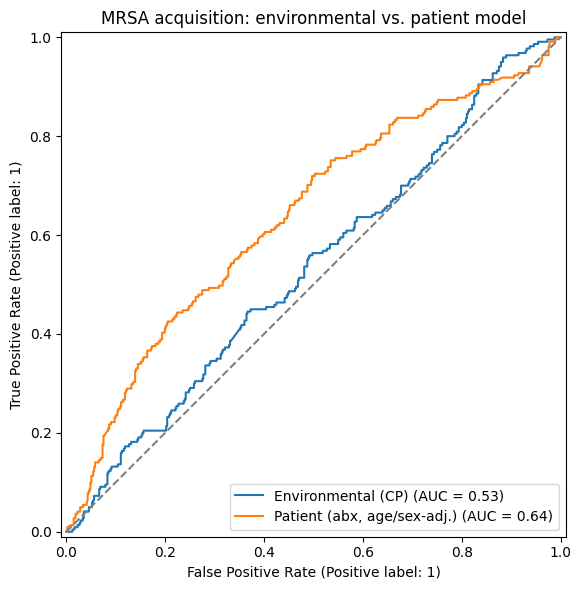

In [3]:
fig, ax = plt.subplots(figsize=(6, 6))
RocCurveDisplay.from_estimator(env_clf, env_X_test, env_y_test, ax=ax, name="Environmental (CP)")
RocCurveDisplay.from_estimator(pat_clf, pat_X_test, pat_y_test, ax=ax, name="Patient (abx, age/sex-adj.)")
ax.plot([0, 1], [0, 1], linestyle="--", color="grey")
ax.set_title("MRSA acquisition: environmental vs. patient model")
plt.tight_layout()

## Performance summary table

In [4]:
summary = pd.DataFrame({
    "model": ["Environmental (colonization pressure)", "Patient (antibiotic exposure, age/sex-adj.)"],
    "n": [len(env), len(pat)],
    "test_AUC": [env_auc, pat_auc],
})
summary

,model,n,test_AUC
0,Environmental (colonization pressure),3498,0.533665
1,"Patient (antibiotic exposure, age/sex-adj.)",3758,0.637067


## Conclusion

**The patient (antibiotic exposure, age/sex-adjusted) model clearly outperforms the
environmental (colonization pressure) model on held-out predictive performance:
AUC 0.637 vs. 0.534.** The environmental model is barely better than chance.

Two important qualifications, both pointing the same direction, that belong in the
write-up:

1. **Not apples-to-apples.** The two cohorts differ in matching design and composition
   (see the caveat at the top of this notebook), so part of the AUC gap could reflect the
   cohorts themselves rather than the predictor classes.
2. **The patient model's advantage may be mostly age/sex, not antibiotics.** In
   `04b_logreg_patient.ipynb`, `sex_male` (OR≈1.84, p<0.001) and `age` (p<0.001) are by
   far the strongest, most significant terms in the adjusted model — individual
   antibiotic-class coefficients are mostly non-significant. Pseudo-R² nearly quadrupled
   (0.0067 → 0.0296) specifically from *adding* age/sex, not from the antibiotic terms
   already in the unadjusted model. That's expected, since the patient cohort — unlike
   the environmental one — wasn't matched on age/sex, so those variables were doing real,
   previously-unmodeled work.

So the honest framing is narrower than "antibiotic exposure beats colonization
pressure": **this dataset's patient-level demographic and exposure history collectively
predict hospital-onset MRSA acquisition meaningfully better than ward-level colonization
pressure does, but demographics (age/sex) — not the antibiotic classes specifically —
account for most of that gap.** Colonization pressure's one genuine signal
(`MRSA_cp`, OR 1.069, p=0.010 in `04a`) is real but small next to that.